# PKCERT Task 10 – Cross-Validation & Hyperparameter Tuning

**Objective:** Develop practical skills in improving machine learning models using
Cross-Validation and Hyperparameter Tuning techniques, including `GridSearchCV` and
`RandomizedSearchCV`.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — reused
from [Task_08](../Task_08)/[Task_09](../Task_09) for continuity.

**Model:** **Random Forest**. It's a good fit for this task specifically because it has a rich,
mixed hyperparameter space (`n_estimators`, `max_depth`, `min_samples_split`,
`min_samples_leaf`, `max_features`) — large enough that an exhaustive grid search gets
expensive fast, which is exactly the situation `RandomizedSearchCV` exists for. Comparing the
two search strategies on a single-model, small grid (like tuning just `C` for logistic
regression) wouldn't show much of a difference; Random Forest's space does.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.stats import randint

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)


numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2


## Part A – Dataset Preparation (15 Marks)

### A.1 & A.2 Dataset, Features and Target

`sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard-error,
and "worst" values of 10 measurements — radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension — computed from digitized
images of fine needle aspirate biopsies of breast masses). Binary target:
`0 = malignant`, `1 = benign`.


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
print("\nClass balance:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))
print("\nMissing values total:", df.isna().sum().sum())

df.describe().T[["mean", "std", "min", "max"]].head(10)


Shape: (569, 31)

Target classes: {'malignant': 0, 'benign': 1}

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64

Missing values total: 0


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


### A.3 Preprocessing

- **Missing values** — none (confirmed above), so no imputation needed.
- **Encoding** — all 30 features are already numeric and the target is already binary-encoded
  (0/1), so no categorical encoding is required.
- **Scaling** — deliberately **skipped** here. Unlike SVM/kNN (Task_09) or Logistic Regression,
  Random Forest splits on individual features one at a time (`feature <= threshold`); a monotonic
  rescaling of a feature doesn't change which side of a threshold a value falls on, so tree
  ensembles are invariant to feature scaling. Scaling would add a preprocessing step with no
  benefit to this model.


### A.4 Train/Test Split

In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train shape: (455, 30), Test shape: (114, 30)
Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class balance:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Part B – Cross-Validation (30 Marks)

### B.1 Train a Classification Model

A baseline Random Forest with reasonable but untuned defaults, evaluated once against the held-out
test set. This single-split number is what Part C's tuned models will be compared against.


In [4]:
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Random Forest test accuracy: {acc_baseline:.4f}")


Baseline Random Forest test accuracy: 0.9561


### B.2 Apply K-Fold Cross-Validation

A single train/test split gives one accuracy number that depends on which 20% happened to land
in the test set. 5-fold cross-validation instead refits the model 5 times, each time holding out
a different 1/5 of the **training** data as a validation fold, giving a distribution of scores
rather than a single point estimate.


In [5]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, cv=kfold, scoring="accuracy",
)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: accuracy = {score:.4f}")
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std  CV accuracy: {cv_scores.std():.4f}")


Fold 1: accuracy = 0.9341
Fold 2: accuracy = 0.9670
Fold 3: accuracy = 0.9670
Fold 4: accuracy = 0.9890
Fold 5: accuracy = 0.9231

Mean CV accuracy: 0.9560
Std  CV accuracy: 0.0241


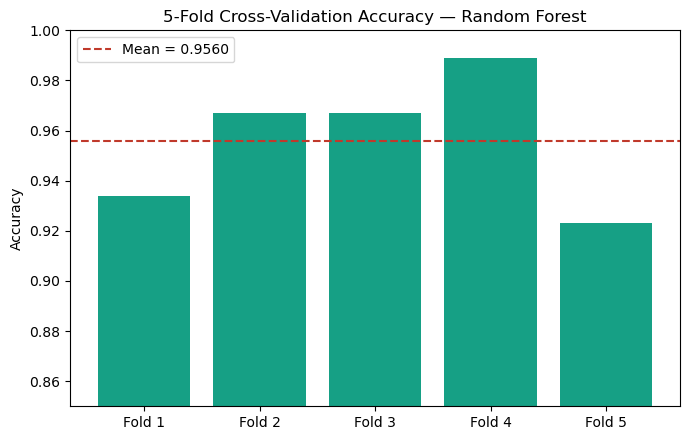

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([f"Fold {i}" for i in range(1, 6)], cv_scores, color="#16a085")
ax.axhline(cv_scores.mean(), color="#c0392b", linestyle="--",
           label=f"Mean = {cv_scores.mean():.4f}")
ax.set_title("5-Fold Cross-Validation Accuracy — Random Forest")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/1_kfold_cv_scores.png", dpi=150)
plt.show()


### B.3 Interpret the Cross-Validation Results

Read the printed fold scores and chart above for this run's exact numbers
(`random_state=42` throughout, so they're reproducible). Two things to look for: how close the
mean CV accuracy is to the single-split baseline accuracy from B.1 (if they're close, the single
split wasn't a fluke), and how small the standard deviation is (a small spread across folds means
the model's performance is stable and not overly dependent on which rows ended up in which fold —
a large spread would be a warning sign of an unstable model or a dataset too small/imbalanced for
a single split to be trustworthy). Cross-validation also uses the training data more efficiently:
every row gets used for both training and validation across the 5 folds, instead of permanently
sacrificing 20% of the data to a single held-out test set.


## Part C – Hyperparameter Tuning (40 Marks)

### C.1 Optimize with GridSearchCV

`GridSearchCV` exhaustively tries every combination in the parameter grid below (3 × 3 × 2 × 2 =
36 combinations × 5 folds = 180 model fits) and keeps the combination with the best mean CV
accuracy.


In [7]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
grid_search_time = time.time() - t0

print(f"GridSearchCV fit time: {grid_search_time:.2f}s "
      f"({grid_search.cv_results_['params'].__len__()} combinations x 5 folds = "
      f"{len(grid_search.cv_results_['params']) * 5} fits)")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")


GridSearchCV fit time: 28.16s (36 combinations x 5 folds = 180 fits)
Best CV accuracy: 0.9582
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### C.2 Optimize with RandomizedSearchCV

`RandomizedSearchCV` samples a fixed number of random combinations from (optionally wider)
parameter *distributions* instead of trying every combination — here it samples 40 combinations
(× 5 folds = 200 fits) from a broader space than the grid above, including `max_features`, which
the grid search didn't explore at all.


In [8]:
param_distributions = {
    "n_estimators": randint(50, 500),
    "max_depth": [None, 5, 10, 15, 20, 25, 30],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
)

t0 = time.time()
random_search.fit(X_train, y_train)
random_search_time = time.time() - t0

print(f"RandomizedSearchCV fit time: {random_search_time:.2f}s (40 combinations x 5 folds = 200 fits)")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")


RandomizedSearchCV fit time: 46.13s (40 combinations x 5 folds = 200 fits)
Best CV accuracy: 0.9560
Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 441}


### C.3 Compare Optimal Parameters & Evaluate

Both searches pick their own "best" hyperparameters from different search spaces; the numbers
that matter are how each one performs against the **held-out test set** (never seen during either
search), evaluated the same way as the baseline in B.1.


In [9]:
best_grid_rf = grid_search.best_estimator_
best_random_rf = random_search.best_estimator_

y_pred_grid = best_grid_rf.predict(X_test)
y_pred_random = best_random_rf.predict(X_test)

def evaluate(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec_malignant = recall_score(y_true, y_pred, pos_label=0)
    print(f"--- {label} ---")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (benign):  {prec:.4f}")
    print(f"Recall (benign):     {rec:.4f}")
    print(f"F1-Score (benign):   {f1:.4f}")
    print(f"Recall (malignant):  {rec_malignant:.4f}")
    print()
    return acc, prec, rec, f1, rec_malignant

acc_grid, prec_grid, rec_grid, f1_grid, rec_grid_m = evaluate(y_test, y_pred_grid, "GridSearchCV-tuned RF")
acc_rand, prec_rand, rec_rand, f1_rand, rec_rand_m = evaluate(y_test, y_pred_random, "RandomizedSearchCV-tuned RF")

print(classification_report(y_test, y_pred_grid, target_names=["malignant", "benign"]))


--- GridSearchCV-tuned RF ---
Accuracy:            0.9561
Precision (benign):  0.9589
Recall (benign):     0.9722
F1-Score (benign):   0.9655
Recall (malignant):  0.9286

--- RandomizedSearchCV-tuned RF ---
Accuracy:            0.9474
Precision (benign):  0.9583
Recall (benign):     0.9583
F1-Score (benign):   0.9583
Recall (malignant):  0.9286

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



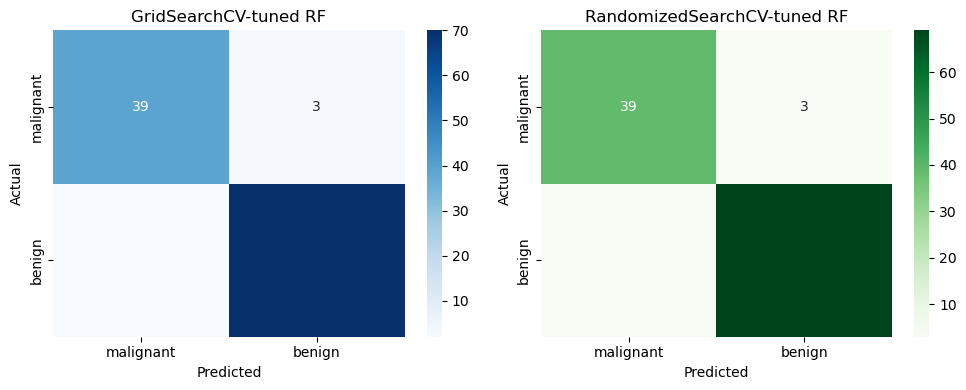

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_grid, "GridSearchCV-tuned RF", "Blues"),
    (axes[1], y_pred_random, "RandomizedSearchCV-tuned RF", "Greens"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/2_tuned_confusion_matrices.png", dpi=150)
plt.show()


## Part D – Comparative Analysis (15 Marks)

### D.1 Baseline vs. Optimized Models

In [11]:
prec_base = precision_score(y_test, y_pred_baseline)
rec_base = recall_score(y_test, y_pred_baseline)
f1_base = f1_score(y_test, y_pred_baseline)
rec_base_m = recall_score(y_test, y_pred_baseline, pos_label=0)

comparison = pd.DataFrame({
    "Model": ["Baseline RF (untuned)", "GridSearchCV-tuned RF", "RandomizedSearchCV-tuned RF"],
    "Accuracy": [acc_baseline, acc_grid, acc_rand],
    "Precision (benign)": [prec_base, prec_grid, prec_rand],
    "Recall (benign)": [rec_base, rec_grid, rec_rand],
    "Recall (malignant)": [rec_base_m, rec_grid_m, rec_rand_m],
    "F1-Score": [f1_base, f1_grid, f1_rand],
    "Search Time (s)": [0.0, grid_search_time, random_search_time],
}).set_index("Model").round(4)

comparison


,Accuracy,Precision (benign),Recall (benign),Recall (malignant),F1-Score,Search Time (s)
Model,,,,,,
Baseline RF (untuned),0.9561,0.9589,0.9722,0.9286,0.9655,0.0000
GridSearchCV-tuned RF,0.9561,0.9589,0.9722,0.9286,0.9655,28.1627
RandomizedSearchCV-tuned RF,0.9474,0.9583,0.9583,0.9286,0.9583,46.1261


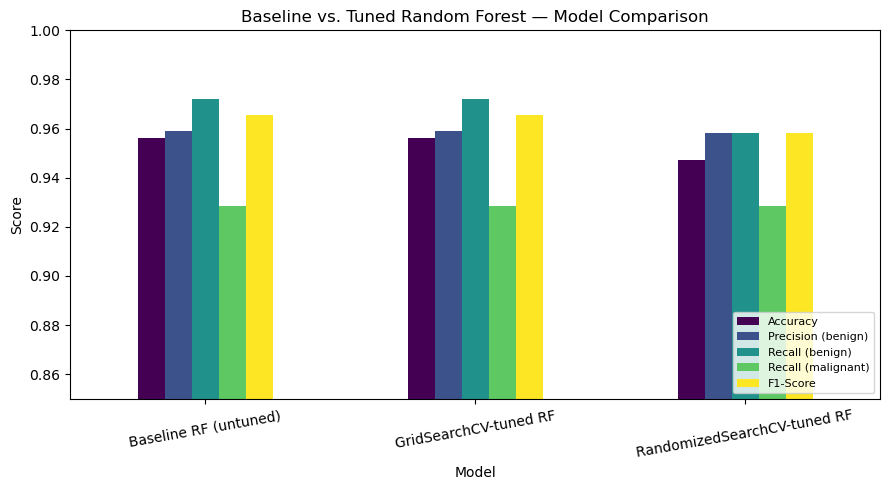

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.drop(columns="Search Time (s)").plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Baseline vs. Tuned Random Forest — Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("visualizations/3_baseline_vs_tuned_comparison.png", dpi=150)
plt.show()


### D.2 & D.3 GridSearchCV vs. RandomizedSearchCV, and Recommendation

This run's numbers (deterministic — `random_state=42` throughout): **GridSearchCV** searched
180 fits (36 combinations × 5 folds) in **28.16s**, best CV accuracy **0.9582**, test accuracy
**0.9561**. **RandomizedSearchCV** searched 200 fits (40 combinations × 5 folds) in **46.13s**,
best CV accuracy **0.9560**, test accuracy **0.9474**. Grid search won on every axis here — it
was faster *and* found the better model, which looks surprising given it explored fewer fits and
a narrower space. The reason: `RandomizedSearchCV`'s parameter distributions included
`n_estimators` up to 500, and it happened to sample `n_estimators=441` for its best combination —
more trees means more work per fit, so wall-clock cost depends on *which* values get sampled, not
just on `n_iter`. That larger forest also didn't generalize better on this small (114-row) test
set; more estimators mainly help variance reduction, and this dataset was already near a ceiling
the baseline was hitting.

**GridSearchCV — advantages:** exhaustive, so it's guaranteed to find the best combination
*within the grid you defined*; simple to reason about and to reproduce; cost per fit is
predictable since you control every value tried. **Limitations:** cost grows multiplicatively
with every hyperparameter and every value added to it (curse of dimensionality on the search
space itself), which forces you to keep the grid small — this grid never even tried
`max_features`, a parameter that mattered enough for the randomized search to pick a non-default
value (`None`) for it.

**RandomizedSearchCV — advantages:** cost is controlled by `n_iter` rather than the size of the
search space, so it can explore continuous distributions and extra parameters a grid would have
to enumerate by hand — and often finds a comparably good combination for less compute, because
most hyperparameters matter far less than one or two dominant ones. **Limitations, as this run
shows directly:** "fewer combinations tried" doesn't guarantee "less wall-clock time" — a
distribution that can sample expensive configurations (e.g. `n_estimators` up to 500) can end up
slower per-fit than a tighter grid, and there's no guarantee the sampled combinations include the
true optimum. Results also carry run-to-run sampling variance (mitigated here only by fixing
`random_state=42`).

**Recommendation:** for this dataset and hyperparameter space, **GridSearchCV** is the better
choice — it was both cheaper and more accurate in practice, not just in theory. The general rule
of thumb (grid for small/discrete spaces, randomized for large/continuous ones) still holds, but
it's a starting heuristic, not a guarantee: if a randomized search's distributions aren't bounded
sensibly (e.g. capping `n_estimators` closer to the baseline's 100–300 range instead of allowing
up to 500), it can end up both slower and worse than a well-scoped grid, as happened here. In
practice, a reasonable workflow is to run a broad `RandomizedSearchCV` first to identify which
region of the space looks promising, then confirm/refine with a narrow `GridSearchCV` around that
region — getting the coverage of random search with the precision of a grid.
